# 02 — GARCH Volatility Modelling & Regime Definition
**Why GARCH?** ACF of squared returns showed significant autocorrelation → volatility clusters.
GARCH(1,1) models this. We use its **conditional volatility output** to define market regimes
(Low Vol vs High Vol) — which is statistically grounded, unlike arbitrary date splits.

## Setup & Data Load

In [3]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.5 MB/s eta 0:00:00


In [1]:
from google.colab import files
files.upload()

Saving gold_silver.csv to gold_silver.csv


{'gold_silver.csv': b'ID_Column,Date,usd_idx,gold,silver,interest,vix,au_returns,ag_returns,au_vol,ag_vol,au_mean,ag_mean\n0,2010-03-03,79.9800033569336,1142.699951171875,17.30900001525879,3.625,18.829999923706055,0.005088558812882546,0.015428325982542965,0.01454598124843938,0.024607414386918318,0.0016277212453685555,0.001839820251424261\n1,2010-03-04,80.55999755859375,1132.5999755859375,17.1560001373291,3.6059999465942383,18.719999313354492,-0.008877987298245592,-0.008878623666452798,0.014523091700857109,0.024704694142606762,0.0006433939642808489,0.0011802801490433572\n2,2010-03-05,80.43000030517578,1134.800048828125,17.36199951171875,3.681999921798706,17.420000076293945,0.0019406138387151374,0.011935907186694364,0.01445890974812581,0.024007617757661553,0.0009921887214231727,0.002976452283681709\n3,2010-03-08,80.43000030517578,1123.5999755859375,17.25200080871582,3.7079999446868896,17.790000915527344,-0.009918672460992171,-0.0063557561838186154,0.010290228806466599,0.01918771148213192

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('gold_silver.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df = df.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Loaded: {df.shape[0]} rows, {df.index[0].date()} → {df.index[-1].date()}")

Loaded: 4092 rows, 2010-03-03 → 2026-06-12


## 1. Fit GARCH(1,1) — Gold

In [7]:
# GARCH works better with returns scaled to percentage points
returns_au = df['au_returns'] * 100

garch_au = arch_model(returns_au, vol='Garch', p=1, q=1, dist='normal', mean='Constant')
fit_au   = garch_au.fit(disp='off')
print(fit_au.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             au_returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5794.48
Distribution:                  Normal   AIC:                           11597.0
Method:            Maximum Likelihood   BIC:                           11622.2
                                        No. Observations:                 4092
Date:                Tue, Jun 16 2026   Df Residuals:                     4091
Time:                        10:45:27   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0203  1.550e-02      1.311      0.190 

## 2. Fit GARCH(1,1) — Silver

In [8]:
returns_ag = df['ag_returns'] * 100

garch_ag = arch_model(returns_ag, vol='Garch', p=1, q=1, dist='normal', mean='Constant')
fit_ag   = garch_ag.fit(disp='off')
print(fit_ag.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             ag_returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8373.64
Distribution:                  Normal   AIC:                           16755.3
Method:            Maximum Likelihood   BIC:                           16780.5
                                        No. Observations:                 4092
Date:                Tue, Jun 16 2026   Df Residuals:                     4091
Time:                        10:45:34   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         7.0333e-04  2.730e-02  2.576e-02      0.979 

## 3. Extract Conditional Volatility

In [9]:
# Conditional vol comes out in %-point units — convert back
df['garch_vol_au'] = fit_au.conditional_volatility / 100
df['garch_vol_ag'] = fit_ag.conditional_volatility / 100

print("GARCH Conditional Volatility Stats:")
print(df[['garch_vol_au','garch_vol_ag']].describe().round(6))

GARCH Conditional Volatility Stats:
       garch_vol_au  garch_vol_ag
count   4092.000000   4092.000000
mean       0.010318      0.019862
std        0.003086      0.008359
min        0.006483      0.011024
25%        0.008442      0.015008
50%        0.009492      0.017796
75%        0.011069      0.021858
max        0.033443      0.102636


## 4. GARCH vs Realized Volatility

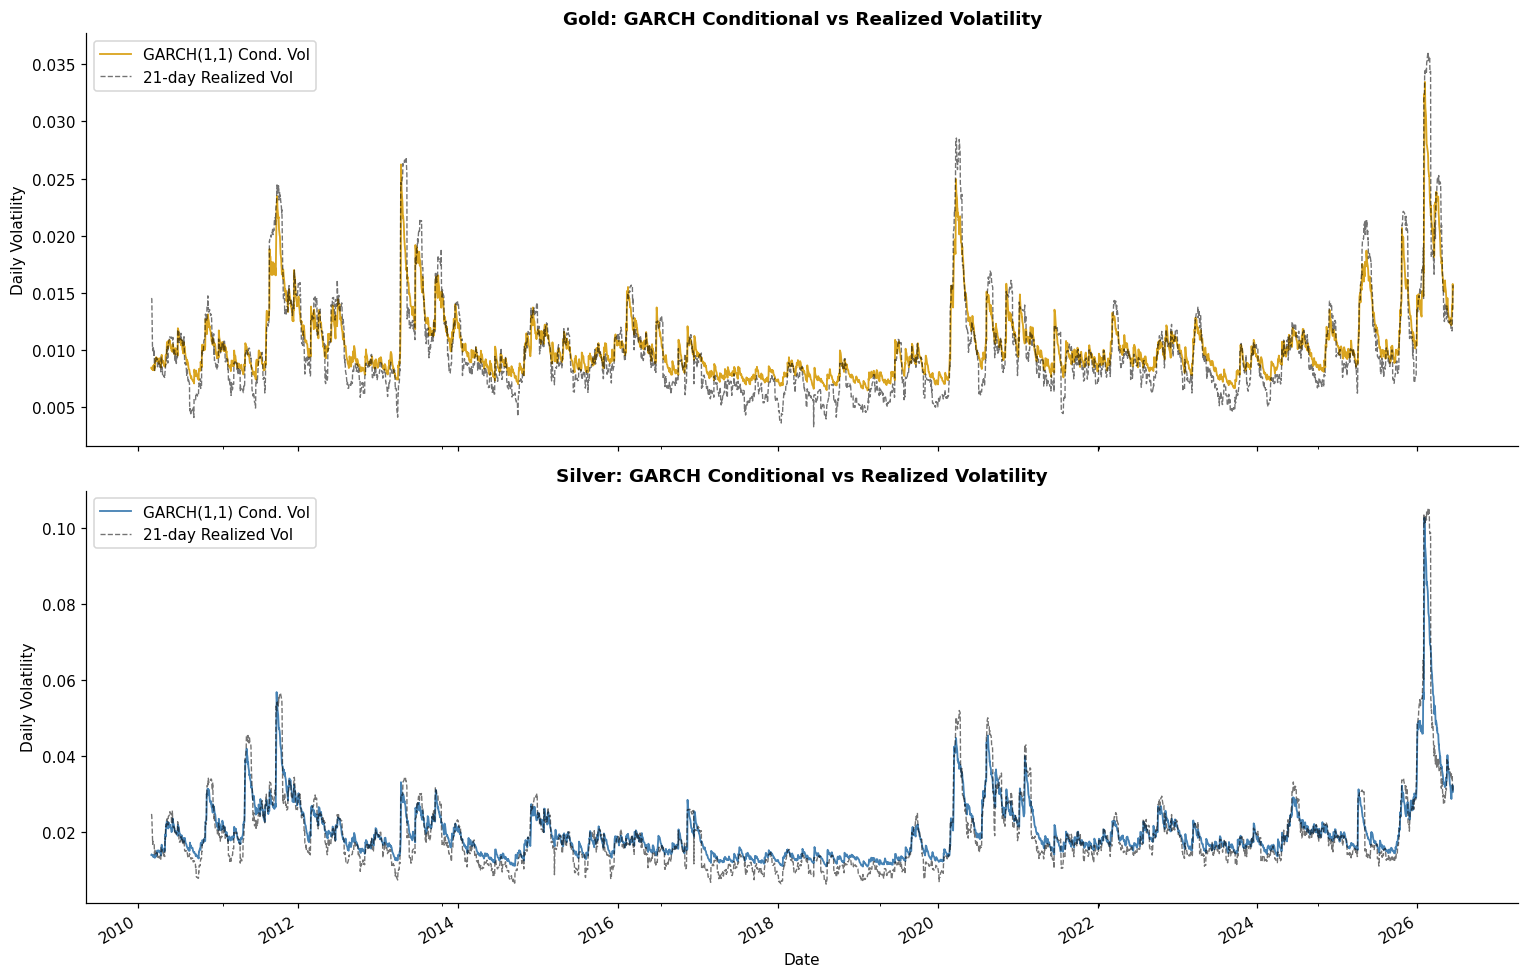

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Gold
df['garch_vol_au'].plot(ax=axes[0], color='goldenrod', linewidth=1.2, label='GARCH(1,1) Cond. Vol')
df['au_vol'].plot(ax=axes[0], color='black', linewidth=0.9, alpha=0.55, linestyle='--', label='21-day Realized Vol')
axes[0].set_title('Gold: GARCH Conditional vs Realized Volatility', fontweight='bold')
axes[0].set_ylabel('Daily Volatility')
axes[0].legend()

# Silver
df['garch_vol_ag'].plot(ax=axes[1], color='steelblue', linewidth=1.2, label='GARCH(1,1) Cond. Vol')
df['ag_vol'].plot(ax=axes[1], color='black', linewidth=0.9, alpha=0.55, linestyle='--', label='21-day Realized Vol')
axes[1].set_title('Silver: GARCH Conditional vs Realized Volatility', fontweight='bold')
axes[1].set_ylabel('Daily Volatility')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Define Volatility Regimes (Median Split)

In [11]:
# Threshold = median conditional volatility over full history
median_vol_au = df['garch_vol_au'].median()
median_vol_ag = df['garch_vol_ag'].median()

print(f"Gold  GARCH vol median: {median_vol_au:.6f}")
print(f"Silver GARCH vol median: {median_vol_ag:.6f}")

df['vol_regime_au'] = np.where(df['garch_vol_au'] >= median_vol_au, 'high_vol', 'low_vol')
df['vol_regime_ag'] = np.where(df['garch_vol_ag'] >= median_vol_ag, 'high_vol', 'low_vol')

print("\nGold Regime Distribution:")
print(df['vol_regime_au'].value_counts())
print("\nSilver Regime Distribution:")
print(df['vol_regime_ag'].value_counts())

Gold  GARCH vol median: 0.009492
Silver GARCH vol median: 0.017796

Gold Regime Distribution:
vol_regime_au
low_vol     2046
high_vol    2046
Name: count, dtype: int64

Silver Regime Distribution:
vol_regime_ag
low_vol     2046
high_vol    2046
Name: count, dtype: int64


## 6. Define Period Regimes (Pre/During/Post-COVID)

In [12]:
def get_period_regime(date):
    if date < pd.Timestamp('2020-03-01'):
        return 'pre_covid'
    elif date <= pd.Timestamp('2021-12-31'):
        return 'covid'
    else:
        return 'post_covid'

df['period_regime'] = df.index.map(get_period_regime)
print("Period Regime Distribution:")
print(df['period_regime'].value_counts())

Period Regime Distribution:
period_regime
pre_covid     2512
post_covid    1115
covid          465
Name: count, dtype: int64


## 7. Visualise Regimes on Price Chart

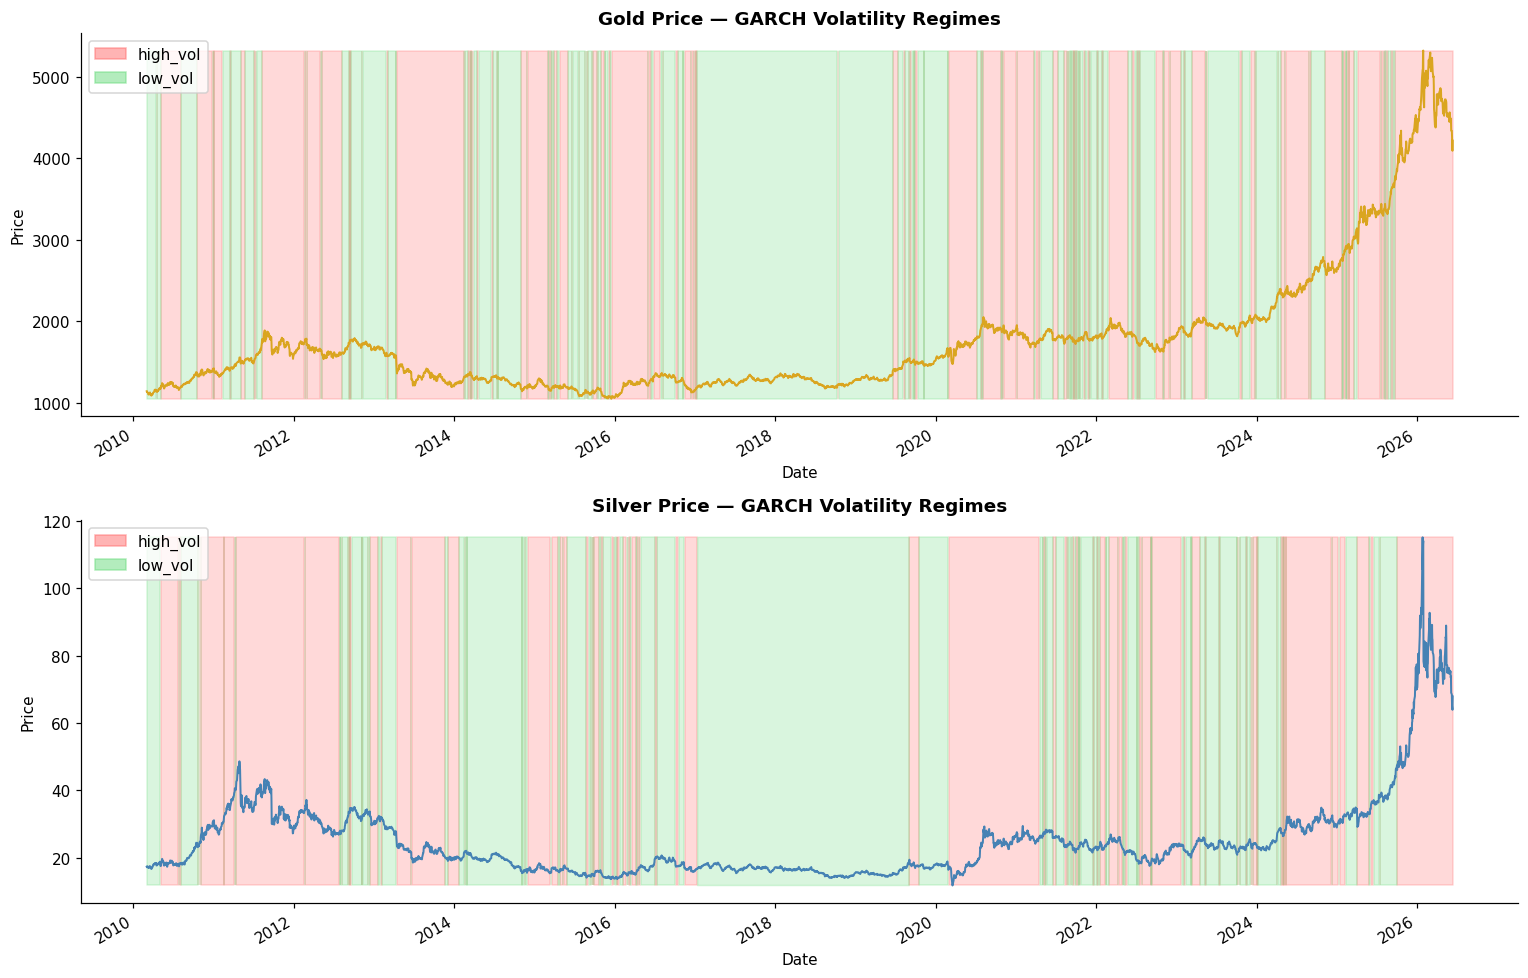

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
colors = {'high_vol': '#FF6B6B', 'low_vol': '#69DB7C'}

for regime, color in colors.items():
    mask = df['vol_regime_au'] == regime
    axes[0].fill_between(df.index, df['gold'].min(), df['gold'].max(),
                         where=mask, alpha=0.25, color=color)
df['gold'].plot(ax=axes[0], color='goldenrod', linewidth=1.3, zorder=5)
axes[0].set_title('Gold Price — GARCH Volatility Regimes', fontweight='bold')
axes[0].set_ylabel('Price')
patches = [mpatches.Patch(color=c, alpha=0.5, label=l) for l, c in colors.items()]
axes[0].legend(handles=patches, loc='upper left')

for regime, color in colors.items():
    mask = df['vol_regime_ag'] == regime
    axes[1].fill_between(df.index, df['silver'].min(), df['silver'].max(),
                         where=mask, alpha=0.25, color=color)
df['silver'].plot(ax=axes[1], color='steelblue', linewidth=1.3, zorder=5)
axes[1].set_title('Silver Price — GARCH Volatility Regimes', fontweight='bold')
axes[1].set_ylabel('Price')
axes[1].legend(handles=patches, loc='upper left')

plt.tight_layout()
plt.show()

## 8. Return Statistics by Regime

In [14]:
def regime_stats(df, return_col, regime_col, asset):
    print(f"\n{'='*55}")
    print(f"  {asset} Return Stats by {regime_col}")
    print(f"{'='*55}")
    grp = df.groupby(regime_col)[return_col]
    stats = grp.agg(['mean','std','min','max',
                     lambda x: (x > 0).mean()]).round(6)
    stats.columns = ['Mean','Std','Min','Max','% Up Days']
    print(stats.to_string())

regime_stats(df, 'au_returns', 'vol_regime_au',  'GOLD   | Vol Regime')
regime_stats(df, 'au_returns', 'period_regime',  'GOLD   | Period Regime')
regime_stats(df, 'ag_returns', 'vol_regime_ag',  'SILVER | Vol Regime')
regime_stats(df, 'ag_returns', 'period_regime',  'SILVER | Period Regime')


  GOLD   | Vol Regime Return Stats by vol_regime_au
                   Mean       Std       Min       Max  % Up Days
vol_regime_au                                                   
high_vol       0.000318  0.012550 -0.120657  0.059054   0.527859
low_vol        0.000322  0.008562 -0.047386  0.045568   0.527859

  GOLD   | Period Regime Return Stats by period_regime
                   Mean       Std       Min       Max  % Up Days
period_regime                                                   
covid          0.000335  0.011740 -0.051069  0.057775   0.556989
post_covid     0.000750  0.011983 -0.120657  0.059054   0.547982
pre_covid      0.000127  0.009934 -0.098206  0.046026   0.513535

  SILVER | Vol Regime Return Stats by vol_regime_ag
                   Mean       Std       Min      Max  % Up Days
vol_regime_ag                                                  
high_vol       0.000454  0.026221 -0.376103  0.13125   0.524438
low_vol        0.000221  0.015404 -0.103427  0.06728   0.5131

## 9. Save Enriched Dataset

In [15]:
df.to_csv('gold_silver_garch.csv')
print("Saved: gold_silver_garch.csv")
print(f"Columns now: {df.columns.tolist()}")
print(f"Shape: {df.shape}")

Saved: gold_silver_garch.csv
Columns now: ['ID_Column', 'usd_idx', 'gold', 'silver', 'interest', 'vix', 'au_returns', 'ag_returns', 'au_vol', 'ag_vol', 'au_mean', 'ag_mean', 'garch_vol_au', 'garch_vol_ag', 'vol_regime_au', 'vol_regime_ag', 'period_regime']
Shape: (4092, 17)


In [16]:
files.download("gold_silver_garch.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>